<a href="https://colab.research.google.com/github/savioshaju/MNIST-Image-Classification-with-CNN/blob/main/minist_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Image Classification with CNN

## 1. Imports and Setup

In [ ]:

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)


(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()

# Normalize

x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension

x_train_full = np.expand_dims(x_train_full, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Fixed validation split

x_train = x_train_full[:50000]
y_train = y_train_full[:50000]

x_val = x_train_full[50000:]
y_val = y_train_full[50000:]

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

TensorFlow Version: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (50000, 28, 28, 1)
Validation: (10000, 28, 28, 1)
Test: (10000, 28, 28, 1)


## 2. Baseline Model

### 2.1 Model Training

In [ ]:
baseline_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train,
    y_train,
    validation_data=(x_val,y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

baseline_model.evaluate(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9290 - loss: 0.2374 - val_accuracy: 0.9788 - val_loss: 0.0740
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9806 - loss: 0.0615 - val_accuracy: 0.9844 - val_loss: 0.0531
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9870 - loss: 0.0422 - val_accuracy: 0.9877 - val_loss: 0.0424
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9897 - loss: 0.0330 - val_accuracy: 0.9887 - val_loss: 0.0418
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9921 - loss: 0.0252 - val_accuracy: 0.9884 - val_loss: 0.0429
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9937 - loss: 0.0205 - val_accuracy: 0.9883 - val_loss: 0.0455
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9948 - loss: 0.0159 - val_accuracy: 0.9911 - val_loss: 0.0347
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9956 - loss: 0.0129 - val_accuracy: 0

[0.040613092482089996, 0.9889000058174133]

In [ ]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

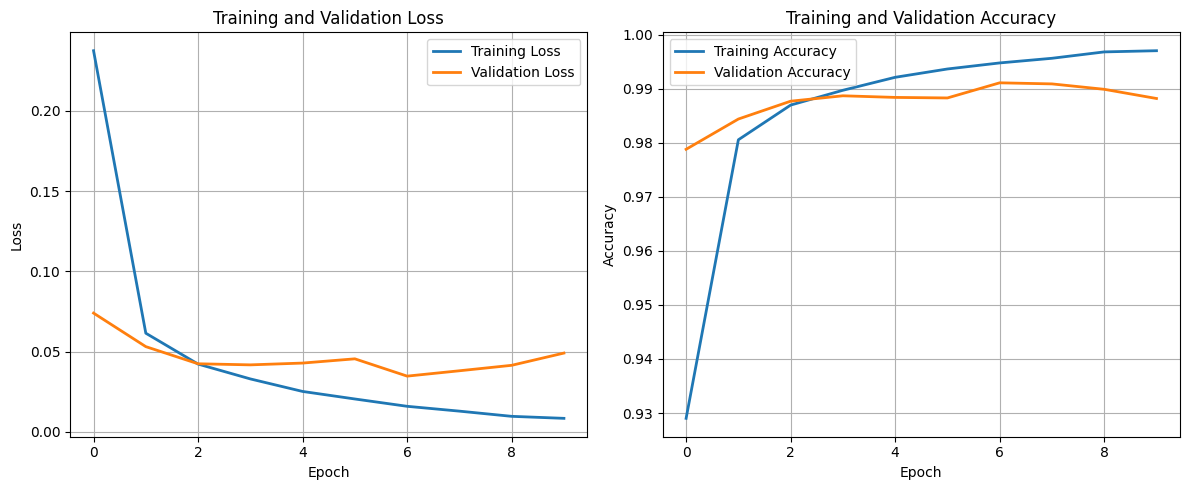

In [ ]:

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history_baseline.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_baseline.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_accuracy = baseline_model.evaluate(x_test, y_test, verbose=0)

print(f"Training Accuracy   : {history_baseline.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history_baseline.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

print(f"Training Loss       : {history_baseline.history['loss'][-1]:.4f}")
print(f"Validation Loss     : {history_baseline.history['val_loss'][-1]:.4f}")
print(f"Test Loss           : {test_loss:.4f}")

Training Accuracy   : 0.9970
Validation Accuracy : 0.9882
Test Accuracy       : 0.9889
Training Loss       : 0.0084
Validation Loss     : 0.0491
Test Loss           : 0.0406


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions for the test set
y_pred_baseline = np.argmax(baseline_model.predict(x_test), axis=1)

# Confusion Matrix
print('Confusion Matrix (Baseline Model):')
print(confusion_matrix(y_test, y_pred_baseline))

# Classification Report
print('\nClassification Report (Baseline Model):')
print(classification_report(y_test, y_pred_baseline))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion Matrix (Baseline Model):
[[ 976    0    1    0    0    0    0    2    1    0]
 [   0 1132    0    0    0    0    2    1    0    0]
 [   1    0 1026    0    1    0    0    4    0    0]
 [   0    0    3 1004    0    2    0    0    1    0]
 [   0    0    0    0  976    0    1    1    0    4]
 [   2    0    1   13    0  873    2    1    0    0]
 [   3    2    0    0    2    1  950    0    0    0]
 [   0    2    7    0    0    0    0 1017    1    1]
 [   4    0   11    7    0    1    2    2  945    2]
 [   1    3    1    0    4    4    0    5    1  990]]

Classification Report (Baseline Model):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.98      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99    

Sample Predictions (Baseline Model):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step


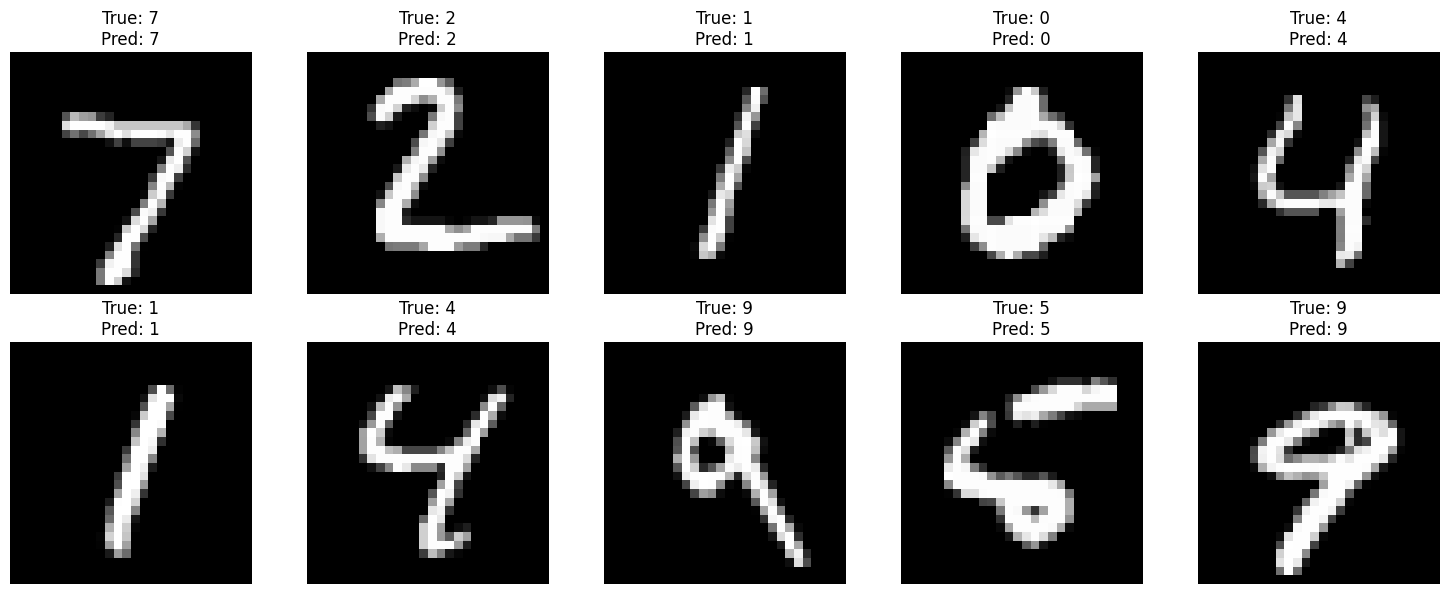

In [ ]:
def plot_predictions(model, x_test, y_test, num_samples=10):
    predictions = np.argmax(model.predict(x_test[:num_samples]), axis=1)
    true_labels = y_test[:num_samples]

    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        plt.title(f'True: {true_labels[i]}\nPred: {predictions[i]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print('Sample Predictions (Baseline Model):')
plot_predictions(baseline_model, x_test, y_test, num_samples=10)

In [ ]:
cd drive/MyDrive/minist

/content/drive/MyDrive/minist


In [ ]:
baseline_model.save("baseline_model.keras")

## 3. Overfitting Model

### 3.1 Model Training (Overfit)

In [ ]:
overfit_model = Sequential([
    tf.keras.Input(shape=(28,28,1)),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(1024,activation='relu'),
    Dense(512,activation='relu'),

    Dense(10,activation='softmax')
])

overfit_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_overfit = overfit_model.fit(
    x_train,
    y_train,
    validation_data=(x_val,y_val),
    epochs=50,
    batch_size=128,
    verbose=1
)
overfit_model.evaluate(x_test,y_test)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9558 - loss: 0.1388 - val_accuracy: 0.9856 - val_loss: 0.0487
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9879 - loss: 0.0384 - val_accuracy: 0.9879 - val_loss: 0.0458
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9923 - loss: 0.0247 - val_accuracy: 0.9884 - val_loss: 0.0430
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9942 - loss: 0.0183 - val_accuracy: 0.9879 - val_loss: 0.0436
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9955 - loss: 0.0140 - val_accuracy: 0.9881 - val_loss: 0.0457
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9955 - loss: 0.0137 - val_accuracy: 0.9914 - val_loss: 0.0367
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9973 - loss: 0.0084 - val_accuracy: 0.9899 - val_loss: 0.0435
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9971 - loss: 0.0091 - val_acc

[0.05840186029672623, 0.9930999875068665]

In [ ]:
overfit_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     6,554,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,143,008 (84.47 MB)

 Trainable params: 7,381,002 (28.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,762,006 (56.31 MB)

In [ ]:
test_loss, test_accuracy = overfit_model.evaluate(x_test, y_test, verbose=0)

print(f"Training Accuracy   : {history_overfit.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history_overfit.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

print(f"Training Loss       : {history_overfit.history['loss'][-1]:.4f}")
print(f"Validation Loss     : {history_overfit.history['val_loss'][-1]:.4f}")
print(f"Test Loss           : {test_loss:.4f}")

Training Accuracy   : 1.0000
Validation Accuracy : 0.9942
Test Accuracy       : 0.9931
Training Loss       : 0.0000
Validation Loss     : 0.0726
Test Loss           : 0.0584


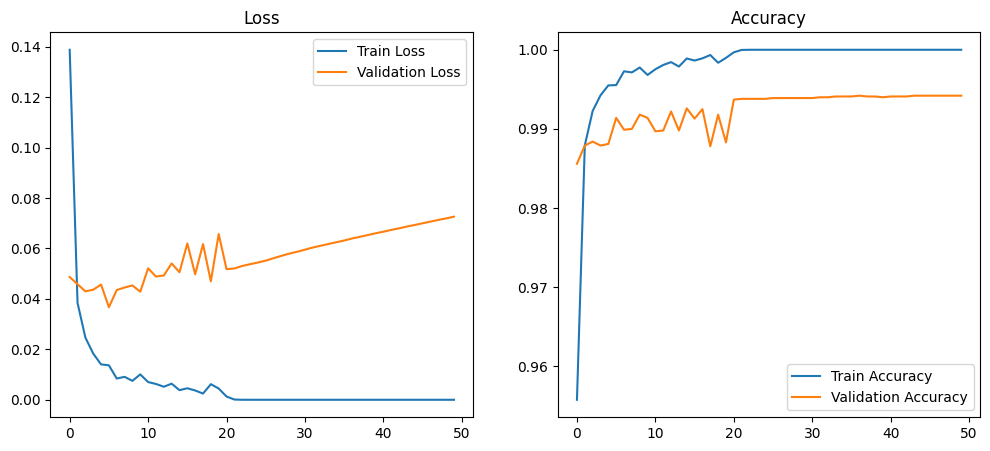

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_overfit.history['loss'], label='Train Loss')
plt.plot(history_overfit.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history_overfit.history['accuracy'], label='Train Accuracy')
plt.plot(history_overfit.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.show()

In [ ]:
y_pred_overfit = np.argmax(overfit_model.predict(x_test), axis=1)

print('Confusion Matrix (Overfit Model):')
print(confusion_matrix(y_test, y_pred_overfit))

print('\nClassification Report (Overfit Model):')
print(classification_report(y_test, y_pred_overfit))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Confusion Matrix (Overfit Model):
[[ 979    0    0    0    0    0    0    1    0    0]
 [   0 1131    0    1    0    1    0    2    0    0]
 [   0    0 1026    0    0    0    0    6    0    0]
 [   0    0    1 1004    0    3    0    1    1    0]
 [   0    0    0    0  975    0    3    0    0    4]
 [   1    0    1    5    0  882    1    1    0    1]
 [   3    2    0    0    2    3  948    0    0    0]
 [   0    2    2    0    0    0    0 1022    0    2]
 [   2    0    0    0    0    0    0    2  967    3]
 [   0    0    0    1    4    3    0    2    2  997]]

Classification Report (Overfit Model):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      

Sample Predictions (Overfit Model):
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step


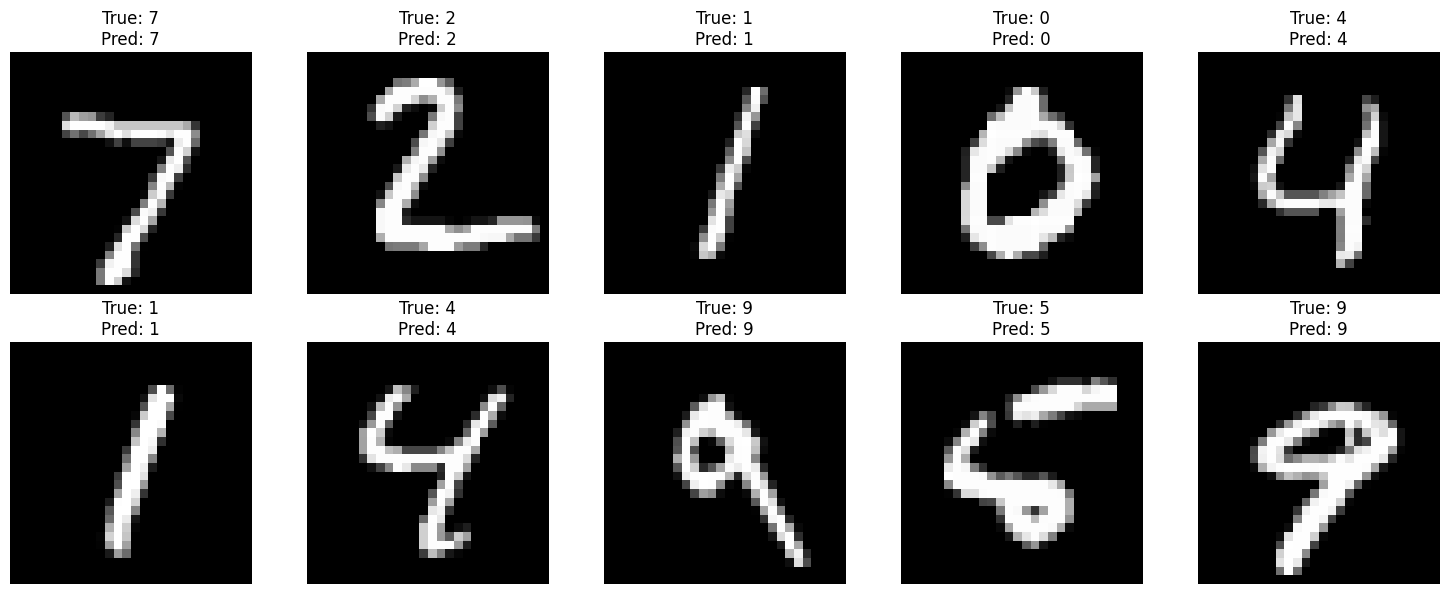

In [ ]:
print('Sample Predictions (Overfit Model):')
plot_predictions(overfit_model, x_test, y_test, num_samples=10)

## 4. Regularized Model

### 4.1 Model Training (Regularized)

In [ ]:
same_arch_model = Sequential([
    tf.keras.Input(shape=(28,28,1)),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(1024,activation='relu'),
    Dense(512,activation='relu'),

    Dense(10,activation='softmax')
])

same_arch_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=0.001,
        weight_decay=1e-4
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(

    ),
    metrics=['accuracy']
)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(x_train)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

history_fixed = same_arch_model.fit(
    datagen.flow(x_train,y_train,batch_size=128),
    validation_data=(x_val,y_val),
    epochs=50,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

same_arch_model.evaluate(x_test,y_test)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.9207 - loss: 0.2463 - val_accuracy: 0.9833 - val_loss: 0.0554 - learning_rate: 0.0010
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.9759 - loss: 0.0776 - val_accuracy: 0.9861 - val_loss: 0.0508 - learning_rate: 0.0010
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.9821 - loss: 0.0586 - val_accuracy: 0.9903 - val_loss: 0.0358 - learning_rate: 0.0010
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9852 - loss: 0.0482 - val_accuracy: 0.9918 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.9863 - loss: 0.0431 - val_accuracy: 0.9926 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.9883 - loss: 0.0377 - val_accuracy: 0.9908 - val_loss: 0.0365 - learning_rate: 0.0010
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.9895 - l

[0.020847396925091743, 0.9945999979972839]

In [ ]:
same_arch_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1024)           │     6,554,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,143,008 (84.47 MB)

 Trainable params: 7,381,002 (28.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,762,006 (56.31 MB)

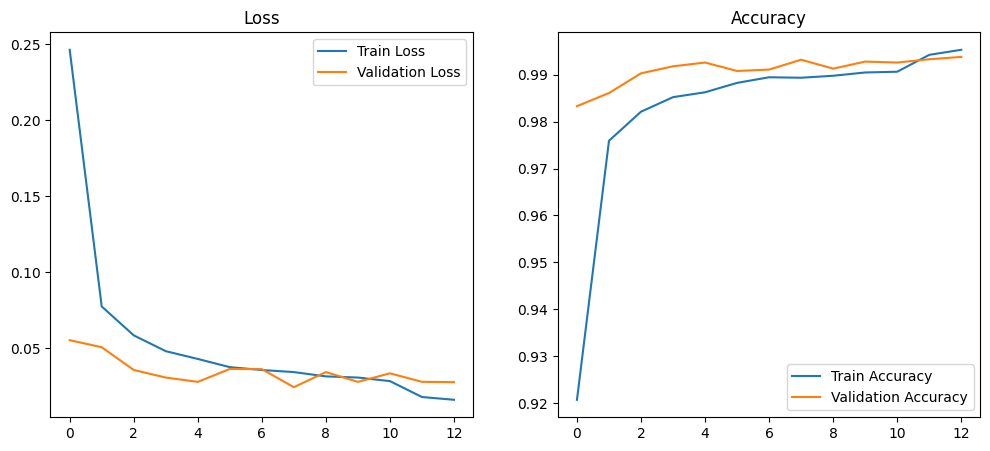

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_fixed.history['loss'], label='Train Loss')
plt.plot(history_fixed.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history_fixed .history['accuracy'], label='Train Accuracy')
plt.plot(history_fixed.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.show()

In [ ]:
test_loss, test_accuracy = same_arch_model.evaluate(x_test, y_test, verbose=0)

print(f"Training Accuracy   : {history_fixed.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history_fixed.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

print(f"Training Loss       : {history_fixed.history['loss'][-1]:.4f}")
print(f"Validation Loss     : {history_fixed.history['val_loss'][-1]:.4f}")
print(f"Test Loss           : {test_loss:.4f}")

Training Accuracy   : 0.9953
Validation Accuracy : 0.9938
Test Accuracy       : 0.9946
Training Loss       : 0.0163
Validation Loss     : 0.0279
Test Loss           : 0.0208


In [ ]:
y_pred_fixed = np.argmax(same_arch_model.predict(x_test), axis=1)

print('Confusion Matrix (Regularized Model):')
print(confusion_matrix(y_test, y_pred_fixed))

print('\nClassification Report (Regularized Model):')
print(classification_report(y_test, y_pred_fixed))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Confusion Matrix (Regularized Model):
[[ 975    0    0    0    0    0    2    1    2    0]
 [   1 1131    1    0    0    0    1    1    0    0]
 [   1    5 1022    1    0    0    0    3    0    0]
 [   0    0    0 1009    0    1    0    0    0    0]
 [   0    0    0    0  981    0    0    0    0    1]
 [   0    0    0    5    0  886    1    0    0    0]
 [   0    1    0    0    2    0  954    0    1    0]
 [   0    0    3    2    0    0    0 1022    0    1]
 [   0    0    0    4    0    0    0    1  968    1]
 [   0    0    0    0    4    4    0    2    1  998]]

Classification Report (Regularized Model):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.

Sample Predictions (Regularized Model):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


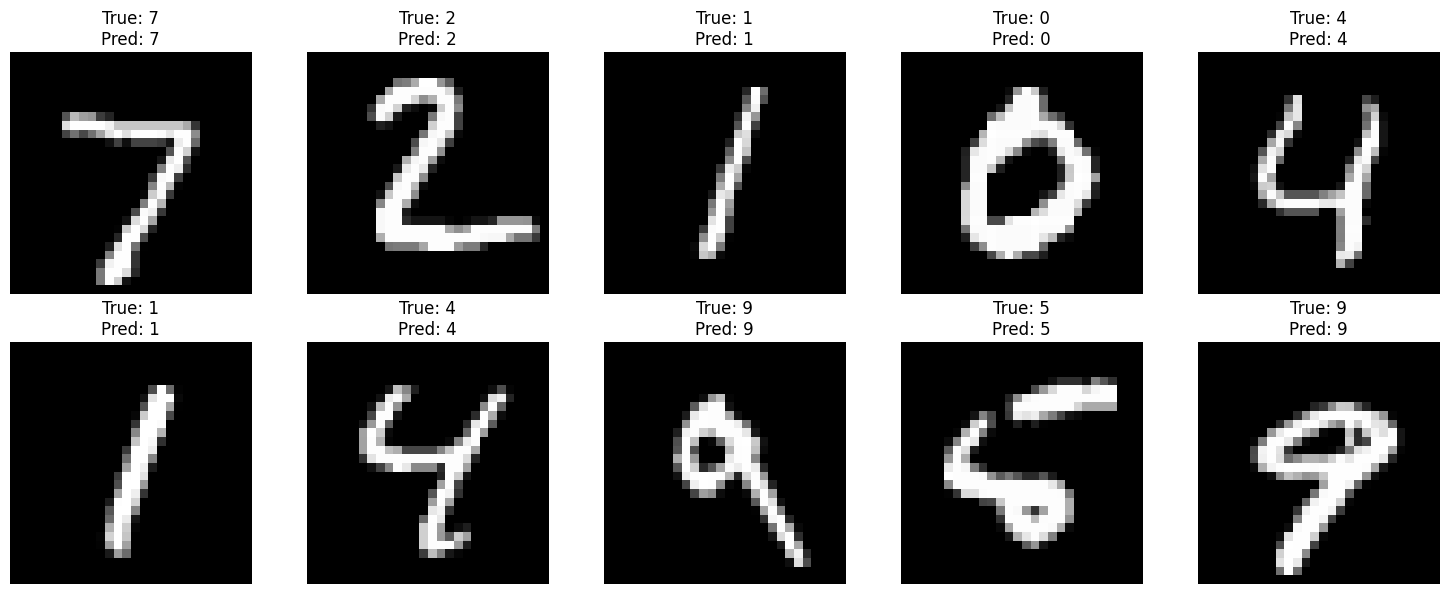

In [ ]:
print('Sample Predictions (Regularized Model):')
plot_predictions(same_arch_model, x_test, y_test, num_samples=10)

In [ ]:
cd drive/MyDrive/minist

[Errno 2] No such file or directory: 'drive/MyDrive/minist'
/content/drive/MyDrive/minist


In [ ]:
same_arch_model.save("same_arch_model.keras")

In [ ]:
ls

baseline_model.keras  same_arch_model.keras
